# Brazilian Real Estate Market Analysis

## Project Overview

## Project Overview

This project analyzes housing data from Brazil to understand regional differences in the real estate market and examine the relationship between property size and price. The analysis involves cleaning raw datasets, performing exploratory data analysis (EDA), and creating visualizations to identify patterns and trends.  

The project focuses particularly on properties in the Southern region of Brazil, where the relationship between property size and price is explored in more detail.

## Project Objectives

The main objectives of this project are:

- Clean and prepare real estate datasets for analysis

- Explore housing price distributions across regions

- Visualize differences in property sizes and prices

- Analyze the relationship between property size and housing price

- Identify regional trends in the Brazilian housing market

In [1]:
-- Explore the data in the table
SELECT *
FROM 'brasil-real-estate-1.csv'
LIMIT 5

,property_type,place_with_parent_names,region,lat-lon,area_m2,price_usd
0,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6443051,-35.7088142",110.0,"$187,230.85"
1,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6430934,-35.70484",65.0,"$81,133.37"
2,house,|Brasil|Alagoas|Maceió|,Northeast,"-9.6227033,-35.7297953",211.0,"$154,465.45"
3,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.622837,-35.719556",99.0,"$146,013.20"
4,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.654955,-35.700227",55.0,"$101,416.71"


### 1. Import Libraries

In [2]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt  
import plotly.express as px    

**Explanation**

- **pandas** – used for data manipulation and analysis

- **matplotlib** – used for creating charts and plots

- **plotly** – used for interactive maps and visualizations

### 2. Load the First Dataset

In [3]:
# Load the first real estate dataset
df1 = pd.read_csv("brasil-real-estate-1.csv")

# Display the first rows of the dataset
df1.head()

,property_type,place_with_parent_names,region,lat-lon,area_m2,price_usd
0,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6443051,-35.7088142",110.0,"$187,230.85"
1,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6430934,-35.70484",65.0,"$81,133.37"
2,house,|Brasil|Alagoas|Maceió|,Northeast,"-9.6227033,-35.7297953",211.0,"$154,465.45"
3,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.622837,-35.719556",99.0,"$146,013.20"
4,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.654955,-35.700227",55.0,"$101,416.71"


**Insight**

This step loads the dataset into a DataFrame and allows us to preview the structure of the data.

### 3. Inspect the Dataset

In [4]:
# View information about the dataset
df1.info()

# Preview the first few rows
df1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12834 entries, 0 to 12833
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   property_type            12834 non-null  object 
 1   place_with_parent_names  12834 non-null  object 
 2   region                   12834 non-null  object 
 3   lat-lon                  11551 non-null  object 
 4   area_m2                  12834 non-null  float64
 5   price_usd                12834 non-null  object 
dtypes: float64(1), object(5)
memory usage: 601.7+ KB


,property_type,place_with_parent_names,region,lat-lon,area_m2,price_usd
0,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6443051,-35.7088142",110.0,"$187,230.85"
1,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6430934,-35.70484",65.0,"$81,133.37"
2,house,|Brasil|Alagoas|Maceió|,Northeast,"-9.6227033,-35.7297953",211.0,"$154,465.45"
3,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.622837,-35.719556",99.0,"$146,013.20"
4,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.654955,-35.700227",55.0,"$101,416.71"


**Insight**

This helps identify:

- Missing values

- Incorrect data types

- Columns that require cleaning

### 4. Remove Missing Values

In [5]:
# Remove rows with missing values
df1 = df1.dropna()

# Confirm the dataset structure after cleaning
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11551 entries, 0 to 12833
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   property_type            11551 non-null  object 
 1   place_with_parent_names  11551 non-null  object 
 2   region                   11551 non-null  object 
 3   lat-lon                  11551 non-null  object 
 4   area_m2                  11551 non-null  float64
 5   price_usd                11551 non-null  object 
dtypes: float64(1), object(5)
memory usage: 631.7+ KB


**Insight**

Removing missing values ensures more reliable analysis.

### 5. Separate Latitude and Longitude

In [6]:
# Split the 'lat-lon' column into two columns: latitude and longitude
df1[["lat", "lon"]] = df1["lat-lon"].str.split(",", expand=True)

# Convert the columns to numeric values
df1["lat"] = df1["lat"].astype(float)
df1["lon"] = df1["lon"].astype(float)

# Preview the updated dataframe
df1.head()

,property_type,place_with_parent_names,region,lat-lon,area_m2,price_usd,lat,lon
0,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6443051,-35.7088142",110.0,"$187,230.85",-9.644305,-35.708814
1,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6430934,-35.70484",65.0,"$81,133.37",-9.643093,-35.704840
2,house,|Brasil|Alagoas|Maceió|,Northeast,"-9.6227033,-35.7297953",211.0,"$154,465.45",-9.622703,-35.729795
3,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.622837,-35.719556",99.0,"$146,013.20",-9.622837,-35.719556
4,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.654955,-35.700227",55.0,"$101,416.71",-9.654955,-35.700227


**Insight**

Separating coordinates allows geographic visualization of properties.

### 6. Extract State Information

In [7]:
# Extract the state name from the location column
df1["state"] = df1["place_with_parent_names"].str.split("|").str[2]

df1.head()

,property_type,place_with_parent_names,region,lat-lon,area_m2,price_usd,lat,lon,state
0,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6443051,-35.7088142",110.0,"$187,230.85",-9.644305,-35.708814,Alagoas
1,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6430934,-35.70484",65.0,"$81,133.37",-9.643093,-35.704840,Alagoas
2,house,|Brasil|Alagoas|Maceió|,Northeast,"-9.6227033,-35.7297953",211.0,"$154,465.45",-9.622703,-35.729795,Alagoas
3,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.622837,-35.719556",99.0,"$146,013.20",-9.622837,-35.719556,Alagoas
4,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.654955,-35.700227",55.0,"$101,416.71",-9.654955,-35.700227,Alagoas


**Insight**

This enables regional analysis of the housing market.

### 7. Convert Price to Numeric Format

In [8]:
# Convert the price column from string to float
df1["price_usd"] = (
    df1["price_usd"]
    .str.replace("$", "")
    .str.replace(",", "")
    .astype(float)
)

df1.head()

,property_type,place_with_parent_names,region,lat-lon,area_m2,price_usd,lat,lon,state
0,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6443051,-35.7088142",110.0,187230.85,-9.644305,-35.708814,Alagoas
1,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6430934,-35.70484",65.0,81133.37,-9.643093,-35.704840,Alagoas
2,house,|Brasil|Alagoas|Maceió|,Northeast,"-9.6227033,-35.7297953",211.0,154465.45,-9.622703,-35.729795,Alagoas
3,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.622837,-35.719556",99.0,146013.20,-9.622837,-35.719556,Alagoas
4,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.654955,-35.700227",55.0,101416.71,-9.654955,-35.700227,Alagoas


**Insight**

Converting prices to numeric format allows calculations and statistical analysis.

### 8. Remove Unnecessary Columns

In [9]:
# Drop columns that are no longer needed
df1 = df1.drop(columns=["lat-lon", "place_with_parent_names"])

df1.head()

,property_type,region,area_m2,price_usd,lat,lon,state
0,apartment,Northeast,110.0,187230.85,-9.644305,-35.708814,Alagoas
1,apartment,Northeast,65.0,81133.37,-9.643093,-35.704840,Alagoas
2,house,Northeast,211.0,154465.45,-9.622703,-35.729795,Alagoas
3,apartment,Northeast,99.0,146013.20,-9.622837,-35.719556,Alagoas
4,apartment,Northeast,55.0,101416.71,-9.654955,-35.700227,Alagoas


### 9. Load the Second Dataset

In [10]:
# Load the second dataset
df2 = pd.read_csv("brasil-real-estate-2.csv")

df2.head()

,property_type,state,region,lat,lon,area_m2,price_brl
0,apartment,Pernambuco,Northeast,-8.134204,-34.906326,72.0,414222.98
1,apartment,Pernambuco,Northeast,-8.126664,-34.903924,136.0,848408.53
2,apartment,Pernambuco,Northeast,-8.125550,-34.907601,75.0,299438.28
3,apartment,Pernambuco,Northeast,-8.120249,-34.895920,187.0,848408.53
4,apartment,Pernambuco,Northeast,-8.142666,-34.906906,80.0,464129.36


### 10. Convert Currency to USD

In [11]:
# Convert BRL to USD
# Historical exchange rate: 1 USD = 3.19 BRL
df2["price_usd"] = df2["price_brl"] / 3.19

df2.head()

,property_type,state,region,lat,lon,area_m2,price_brl,price_usd
0,apartment,Pernambuco,Northeast,-8.134204,-34.906326,72.0,414222.98,129850.463950
1,apartment,Pernambuco,Northeast,-8.126664,-34.903924,136.0,848408.53,265958.786834
2,apartment,Pernambuco,Northeast,-8.125550,-34.907601,75.0,299438.28,93867.799373
3,apartment,Pernambuco,Northeast,-8.120249,-34.895920,187.0,848408.53,265958.786834
4,apartment,Pernambuco,Northeast,-8.142666,-34.906906,80.0,464129.36,145495.097179


### 11. Clean Second Dataset

In [12]:
df2 = df2.drop(columns=["price_brl"])
df2 = df2.dropna()

df2.head()

,property_type,state,region,lat,lon,area_m2,price_usd
0,apartment,Pernambuco,Northeast,-8.134204,-34.906326,72.0,129850.463950
1,apartment,Pernambuco,Northeast,-8.126664,-34.903924,136.0,265958.786834
2,apartment,Pernambuco,Northeast,-8.125550,-34.907601,75.0,93867.799373
3,apartment,Pernambuco,Northeast,-8.120249,-34.895920,187.0,265958.786834
4,apartment,Pernambuco,Northeast,-8.142666,-34.906906,80.0,145495.097179


### 12. Combine Both Datasets

In [13]:
df = pd.concat([df1, df2])

df.head()

,property_type,region,area_m2,price_usd,lat,lon,state
0,apartment,Northeast,110.0,187230.85,-9.644305,-35.708814,Alagoas
1,apartment,Northeast,65.0,81133.37,-9.643093,-35.704840,Alagoas
2,house,Northeast,211.0,154465.45,-9.622703,-35.729795,Alagoas
3,apartment,Northeast,99.0,146013.20,-9.622837,-35.719556,Alagoas
4,apartment,Northeast,55.0,101416.71,-9.654955,-35.700227,Alagoas


**Insight**

Combining datasets gives a more complete view of the housing market.

### 13. Summary Statistics

In [14]:
summary_stats = df[["area_m2","price_usd"]].describe()

summary_stats

,area_m2,price_usd
count,22844.000000,22844.000000
mean,115.020224,194987.315480
std,47.742932,103617.682978
min,53.000000,74892.340000
25%,76.000000,113898.770000
50%,103.000000,165697.555000
75%,142.000000,246900.880878
max,252.000000,525659.717868


**Insight**

Summary statistics provide information about:

- average property size

- average housing price

- minimum and maximum values

### 14. Visualization 1 – Price Distribution

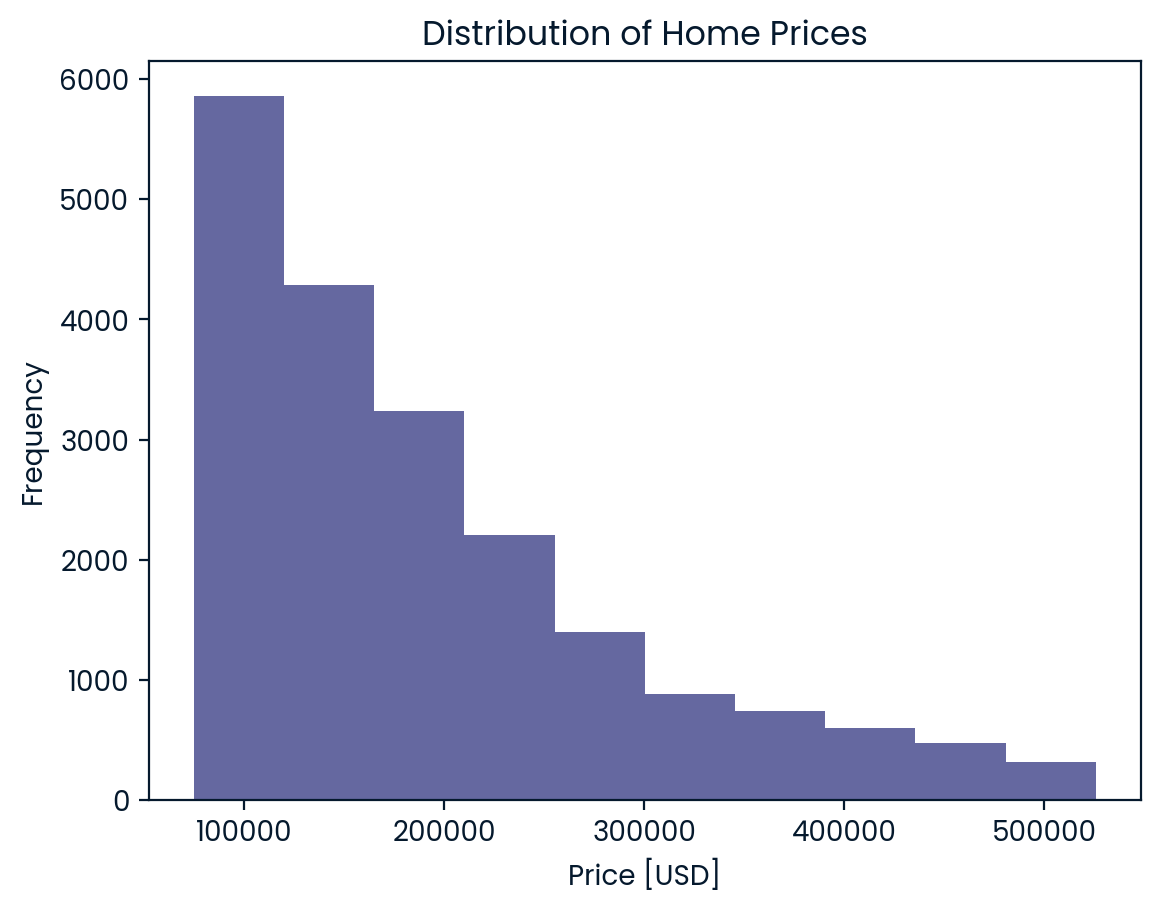

In [15]:
plt.hist(df["price_usd"].head(20000))

plt.xlabel("Price [USD]")
plt.ylabel("Frequency")
plt.title("Distribution of Home Prices")

plt.show()

**Insight**

The histogram shows that:

- Most properties fall within a moderate price range

- A smaller number of homes are extremely expensive

This indicates a **right-skewed distribution**, common in housing markets.

### 15. Visualization 2 – Property Size Distribution

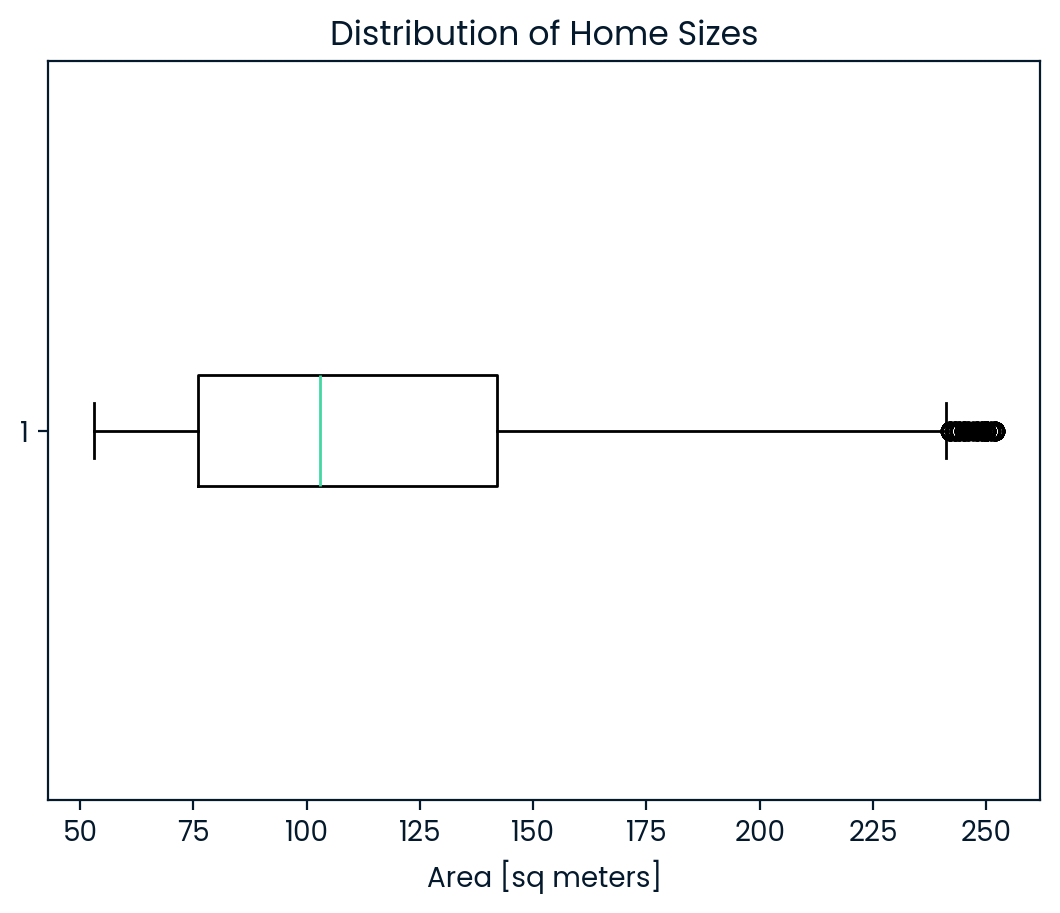

In [16]:
plt.boxplot(df["area_m2"], vert=False)

plt.xlabel("Area [sq meters]")
plt.title("Distribution of Home Sizes")

plt.show()

### 16. Visualization 3 – Mean Price by Region

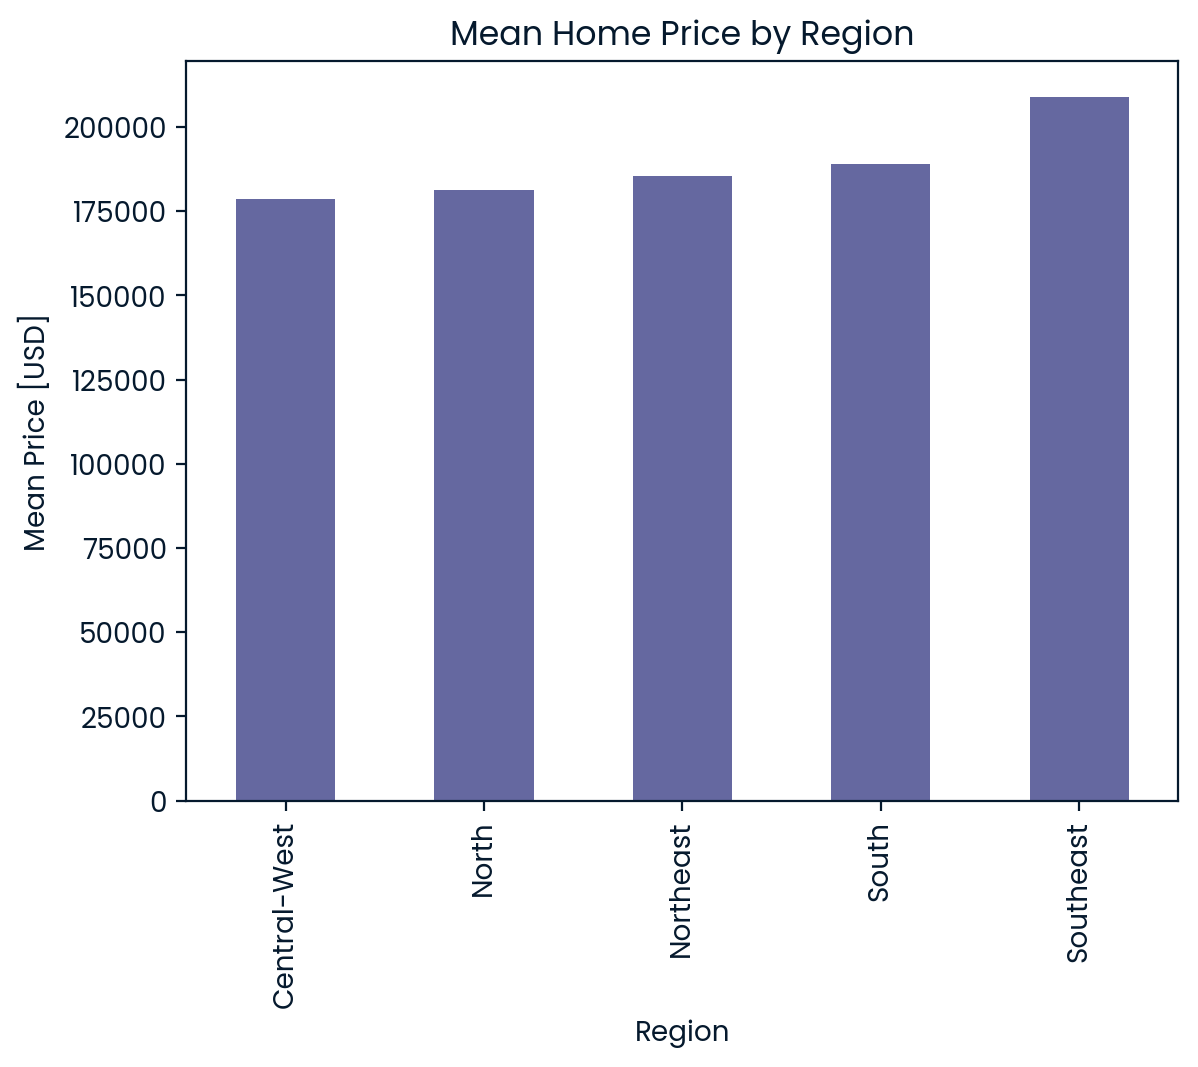

In [17]:
mean_price_by_region = df.groupby("region")["price_usd"].mean().sort_values()

mean_price_by_region.plot.bar()

plt.xlabel("Region")
plt.ylabel("Mean Price [USD]")
plt.title("Mean Home Price by Region")

plt.show()

**Insight**

This visualization highlights significant regional price differences across Brazil.

### 17. Visualization 4 – Property Location Map

In [18]:
fig = px.scatter_mapbox(
    df,
    lat="lat",
    lon="lon",
    color="price_usd",
    size="area_m2",
    zoom=3,
    mapbox_style="open-street-map",
    title="Property Locations in Brazil"
)

fig.show()

**Insight**

The interactive map allows us to see how properties are geographically distributed across Brazil.

### 18. Focus on Southern Region

In [19]:
df_south = df[df["region"] == "South"]

df_south.head()

,property_type,region,area_m2,price_usd,lat,lon,state
9304,apartment,South,127.0,296448.85,-25.455704,-49.292918,Paraná
9305,apartment,South,104.0,219996.25,-25.455704,-49.292918,Paraná
9306,apartment,South,100.0,194210.50,-25.460236,-49.293812,Paraná
9307,apartment,South,77.0,149252.94,-25.460236,-49.293812,Paraná
9308,apartment,South,73.0,144167.75,-25.460236,-49.293812,Paraná


### 19. Homes by State

In [20]:
homes_by_state = df_south["state"].value_counts()

homes_by_state

state
Rio Grande do Sul    2643
Santa Catarina       2634
Paraná               2544
Name: count, dtype: int64

### 20. Visualization – Price vs Area

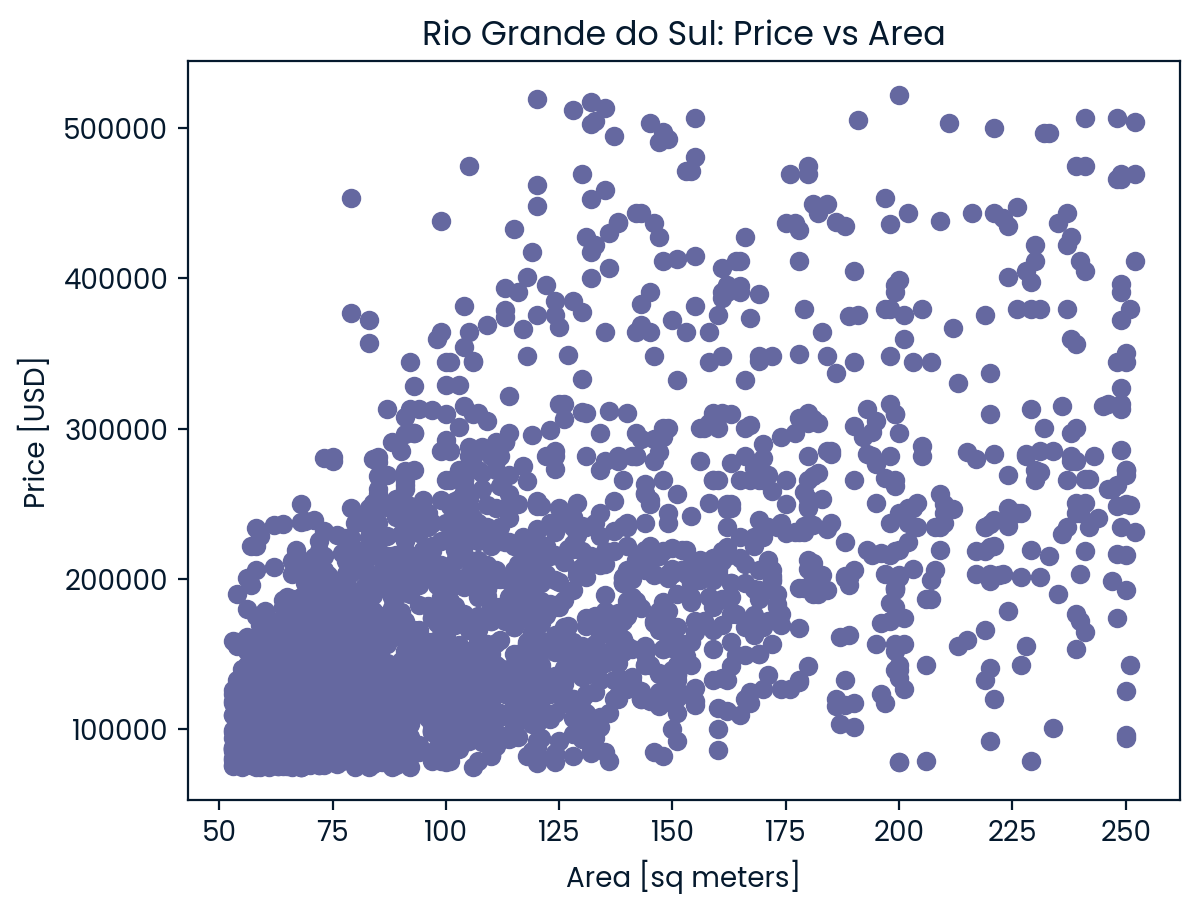

In [21]:
state = homes_by_state.idxmax()

df_state = df_south[df_south["state"] == state]

plt.scatter(df_state["area_m2"], df_state["price_usd"])

plt.xlabel("Area [sq meters]")
plt.ylabel("Price [USD]")
plt.title(f"{state}: Price vs Area")

plt.show()

**Insight**

The scatter plot shows a positive relationship between home size and price.

### 21. Correlation Analysis

In [22]:
south_states = df_south["state"].unique()

south_states_corr = {}

for state in south_states:
    df_state = df_south[df_south["state"] == state]
    corr = df_state["area_m2"].corr(df_state["price_usd"])
    south_states_corr[state] = corr

south_states_corr

{'Paraná': np.float64(0.5436659935502661),
 'Rio Grande do Sul': np.float64(0.5773267433717683),
 'Santa Catarina': np.float64(0.506812177636678)}

**Insight**

Correlation values measure how strongly property size influences price in each state.

## Key Findings

Several important insights emerged from this analysis:

- Housing prices vary significantly across different regions of Brazil.

- The distribution of housing prices is right-skewed, with most homes in moderate price ranges.

- Property size has a positive relationship with price, meaning larger homes generally cost more.

- The strength of this relationship varies between states in the Southern region.

## Conclusion

This project demonstrates how data cleaning, exploratory analysis, and visualization techniques can be used to analyze real estate markets.

The results show that while property size influences housing prices, location also plays a major role in determining property values. Regional economic conditions, housing demand, and geographic factors likely contribute to these differences.

Overall, this analysis highlights how data science tools can be used to extract insights from real estate data and better understand housing market trends.